# Lakeside heating DSM — sklearn hybrid tutorial

> **DO NOT RELEASE FOR OPERATIONAL DSM.** Product claim: **`HYBRID_SCREENING` only**.

This notebook is the **supported train + promote path** for the hybrid Real+E+ ship.
CLI trainers refuse unless `VIBE22_ALLOW_CLI_TRAIN=1`.

| Component | What | Provenance |
|---|---|---|
| A | Real BAS 15-min baseline (7 outs) | `REAL_BAS_15MIN` |
| B | Paired E+ IdealLoads+COP deltas | `ENERGYPLUS_NATIVE_RUN` → delta |
| C | Hybrid 96-step walk | `HYBRID_SCREENING` |

Lean defaults (`FULL=False`, `MAX_DAYS=36`) keep Run All CI-ish. Set `FULL=True` for nested CV on all winter days.


## 1 · Title & multi-output problem

We predict **seven simultaneous outputs** every 15 minutes for one K-12 school day
(96 steps from midnight):

| Index | Target | Unit | Role |
|---|---|---|---|
| 0 | `facility_kw` | kW | Whole-building electric demand (DSM / cost) |
| 1–6 | `zone_temp_*_f` | °F | Six thermal-area air temperatures (comfort) |

Canonical order is locked in `TARGET_COLS` — never reorder heads or ONNX outputs.

```text
 midnight state + future OAT/control
              │
              ▼
        ┌─────────────┐
        │  Surrogate  │
        │   model     │
        └──────┬──────┘
               │
       ┌───────┴────────┐
       ▼                ▼
  96 × facility_kw   96 × 6 zone temps °F
```

```mermaid
flowchart TD
  Midnight["Midnight state + future exogenous/control"] --> Model["Surrogate model"]
  Model --> Kw["96 x facility_kw"]
  Model --> Zones["96 x 6 zone_temp_*_f"]
```

> **Honesty:** ship claim is **`HYBRID_SCREENING` only**.  
> **DO NOT RELEASE FOR OPERATIONAL DSM.**


## 2 · Predictands (what success looks like)

- **Demand fidelity:** morning-peak (HE 05–09) facility MAE/RMSE in **kW**, plus daily peak magnitude/timing and daily kWh error.
- **Comfort fidelity:** per-zone MAE in **°F** — always show the **worst zone**, never hide it behind a mean.
- Metrics live in `metrics_report` (MAE, RMSE, CV(RMSE), NMBE, horizons). Do not invent numbers in Markdown.


## 3 · Multi-output time-series framing

Each row is one 15-min interval. Autoregressive **lags** (`facility_kw_lag1`, zone temp lags, `oat_lag1`)
use only past measured (or previously predicted) values — no future leakage.

Two evaluation modes matter:

| Mode | What the model sees at step *t* | Honesty |
|---|---|---|
| **Teacher-forced (TF)** | True lagged measured targets | Optimistic; good for debugging |
| **Recursive 96-step** | Its own previous predictions as lags | What desktop / DSM walk actually does |

Held-out cards must report **recursive** metrics. Promote rejects `teacher_forced` / `provisional` / `not_evaluated` notes in recursive fields.


## 4 · Real BAS vs EnergyPlus (never concat)

| Stream | Provenance | Role |
|---|---|---|
| **A — Real BAS** | `REAL_BAS_15MIN` | Measured demand + zone temps |
| **B — E+ deltas** | `ENERGYPLUS_NATIVE_RUN` → delta | IdealLoads+COP strategy *differences* |

Hybrid = **baseline(A) + delta(B)** at walk time.  
**Never concatenate BAS∥E+ into one training table** — different physics, different honesty, different confounders.


## 5 · Units & engineering interpretation

- Demand errors are **kW** (or kWh for daily energy) — never present raw MSE as if it were kW.
- Zone errors are **°F**. A ~24 °F zone MAE means the model has not learned temperatures (classic unscaled multi-output failure).
- Peak window: local hour-ending **05–09** (15-min steps ≈ 20–35).


## 6 · Feature contract

Features come from `FEATURE_COLS_15MIN_MT` / `feature_compile_15min` (clock, OAT/HDD, occupancy fractions,
HP/IdealLoads availability, strategy one-hots, lags). Control schedules are versioned under
`contracts/control_strategies_v1/`. Catalog tables below are descriptive — not causal claims.


## 7 · Data quality (descriptive)

Coverage, missingness, target distributions, and one winter-day panel. These plots do **not** replace chronological validation.


## Setup — paths, imports, run_id


In [1]:
from pathlib import Path
import sys, json, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, Markdown

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT / "ml"))
sys.path.insert(0, str(ROOT / "scripts"))

for _mod in (
    "notebook_proof", "notebook_plots", "artifact_paths", "metrics_report",
    "run_provenance", "target_scaling", "chrono_splits",
    "train_real_baseline_15min", "train_eplus_delta_15min", "promote_hybrid_ship",
):
    sys.modules.pop(_mod, None)

from artifact_paths import artifact_paths
from notebook_proof import prove_native_farm_load, prove_real_store_load
from notebook_plots import (
    save_fig, coverage_timeline, missingness_summary, target_distributions,
    winter_day_panel, descriptive_corr_heatmap, feature_target_catalogs,
    family_mae_bars, zone_small_multiples, hybrid_walk_panel, model_comparison_bars,
)
from metrics_report import per_target_table, explain_error_metrics_markdown, scalar_block
from run_provenance import make_run_id, print_artifact_registry, artifact_registry, sha256_file
from target_scaling import assert_target_cols
from chrono_splits import build_split_manifest, write_manifest
from feature_compile_heating_dsm import TARGET_COLS, ZONE_TEMP_COLS
from train_real_baseline_15min import (
    load_real_baseline_frame, lean_bake_off, nested_bake_off, export_real_baseline_artifacts,
)
from train_eplus_delta_15min import (
    load_paired_and_build_delta, lean_train_delta, train_delta, export_delta_artifacts,
)
from promote_hybrid_ship import promote_hybrid, SMOKE_ENV, MIN_PAIRS

PATHS = artifact_paths()
PATHS["figures"].mkdir(parents=True, exist_ok=True)
OUT = PATHS["figures"].parent  # ml/artifacts
SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))

FULL = False
WINTER_ONLY = True
MAX_DAYS = 36 if not FULL else None
N_SPLITS = 3
run_id = make_run_id(prefix="sklearn_tutorial")

print("ROOT", ROOT)
print("SITE", SITE)
print("OUT", OUT)
print("run_id", run_id)
print("FULL", FULL, "MAX_DAYS", MAX_DAYS)
print("honesty HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM")
display(Markdown(explain_error_metrics_markdown()))


ROOT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22
SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside
OUT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts
run_id sklearn_tutorial_20260806T203515Z_eb4a7d
FULL False MAX_DAYS 36
honesty HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM


**MAE** (mean absolute error) is the average |actual − predicted| in engineering units (kW or °F). **RMSE** (root mean squared error) penalizes large misses more heavily; both are reported in the same units as the target — never present raw squared error as kW. **CV(RMSE)** divides RMSE by the mean of actuals when that mean is nonzero. **NMBE** is the mean bias normalized by mean actual (positive ⇒ over-prediction).

## Targets catalog

Seven outputs in locked order — `facility_kw` [kW] then six zone air temperatures [°F].


In [2]:
assert_target_cols(TARGET_COLS)
feat_cat, tgt_cat = feature_target_catalogs(multitarget=True)
display(Markdown("### Targets"))
display(tgt_cat)
display(Markdown("### Features (excerpt)"))
display(feat_cat.head(12))
print("TARGET_COLS", list(TARGET_COLS))


### Targets

,target,role,description
0,facility_kw,prediction,Whole-building electric demand [kW] — primary ...
1,zone_temp_1F_A_f,prediction,Zone air temp Area 1F_A °F (warm-by-start)
2,zone_temp_1F_B_f,prediction,Zone air temp Area 1F_B °F (warm-by-start)
3,zone_temp_1F_C_f,prediction,Zone air temp Area 1F_C °F (warm-by-start)
4,zone_temp_1F_D_f,prediction,Zone air temp Area 1F_D °F (warm-by-start)
5,zone_temp_2F_A_f,prediction,Zone air temp Area 2F_A °F (warm-by-start)
6,zone_temp_2F_B_f,prediction,Zone air temp Area 2F_B °F (warm-by-start)


### Features (excerpt)

,feature,role,description
0,hour_ending,explainer,Hour-ending clock (0–23 local)
1,sin_hour,explainer,Cyclical hour (sin)
2,cos_hour,explainer,Cyclical hour (cos)
3,month,explainer,Calendar month
4,doy,explainer,Day of year
5,is_weekend,explainer,Weekend flag (0/1)
6,occupied,explainer,Occupied flag (generic K12 07–16)
7,oat_f,explainer,Outdoor air temperature °F
8,oat_lag1,explainer (LAG),Prior-hour OAT °F (LAG — no future leak)
9,hdd65,explainer,Heating degree hours base 65°F


TARGET_COLS ['facility_kw', 'zone_temp_1F_A_f', 'zone_temp_1F_B_f', 'zone_temp_1F_C_f', 'zone_temp_1F_D_f', 'zone_temp_2F_A_f', 'zone_temp_2F_B_f']


## Load real BAS store (component A data)


In [3]:
real_df, real_meta = prove_real_store_load(site=SITE)
train_df = load_real_baseline_frame(winter_only=WINTER_ONLY, max_days=MAX_DAYS)
print("train rows", len(train_df), "days", train_df["day"].nunique())
print("provenance check", train_df["provenance"].value_counts().to_dict() if "provenance" in train_df.columns else "n/a")


### Proof — real BAS 15-min store (component A)
- **Parquet:** `C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\ml\artifacts\real_baseline_15min_v1.parquet`
- **Rows / days:** 32156 / 335
- **Provenance:** `REAL_BAS_15MIN` (no EnergyPlus rows)
- **Zone temp columns:** ['zone_temp_1F_A_f', 'zone_temp_1F_B_f', 'zone_temp_1F_C_f', 'zone_temp_1F_D_f', 'zone_temp_2F_A_f', 'zone_temp_2F_B_f']
- **Honesty:** measured BAS only — hybrid baseline component
- **Build row_count:** 32156

,day,step_15,facility_kw,oat_f,zone_temp_1F_A_f,zone_temp_1F_B_f,provenance
0,2025-08-02,0,26.0,56.800000,69.655556,72.295833,REAL_BAS_15MIN
1,2025-08-02,1,24.0,56.566667,69.663889,72.391667,REAL_BAS_15MIN
2,2025-08-02,2,26.0,56.366667,69.586111,72.445833,REAL_BAS_15MIN
3,2025-08-02,3,24.0,56.166667,69.638889,72.454167,REAL_BAS_15MIN
4,2025-08-02,4,28.0,55.966667,69.566667,72.462500,REAL_BAS_15MIN
5,2025-08-02,5,26.0,55.650000,69.625000,72.450000,REAL_BAS_15MIN
6,2025-08-02,6,24.0,55.275000,69.522222,72.425000,REAL_BAS_15MIN
7,2025-08-02,7,26.0,54.900000,69.550000,72.433333,REAL_BAS_15MIN


train rows 3456 days 36
provenance check {'REAL_BAS_15MIN': 3456}


### EDA — coverage, distributions, winter day


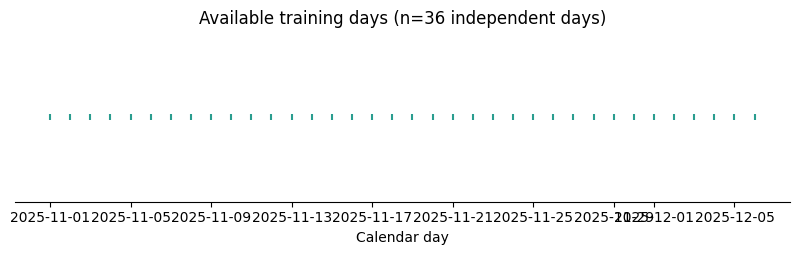

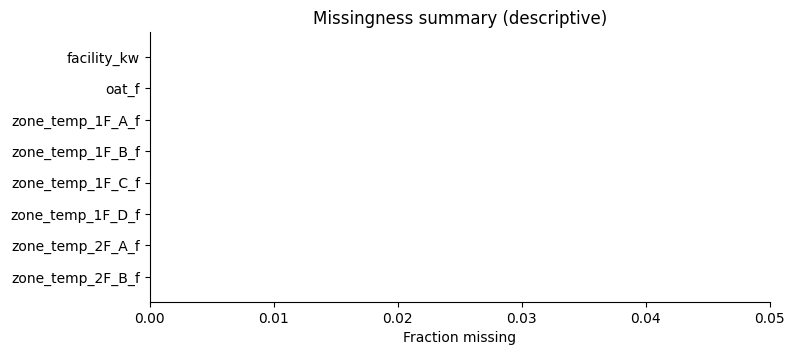

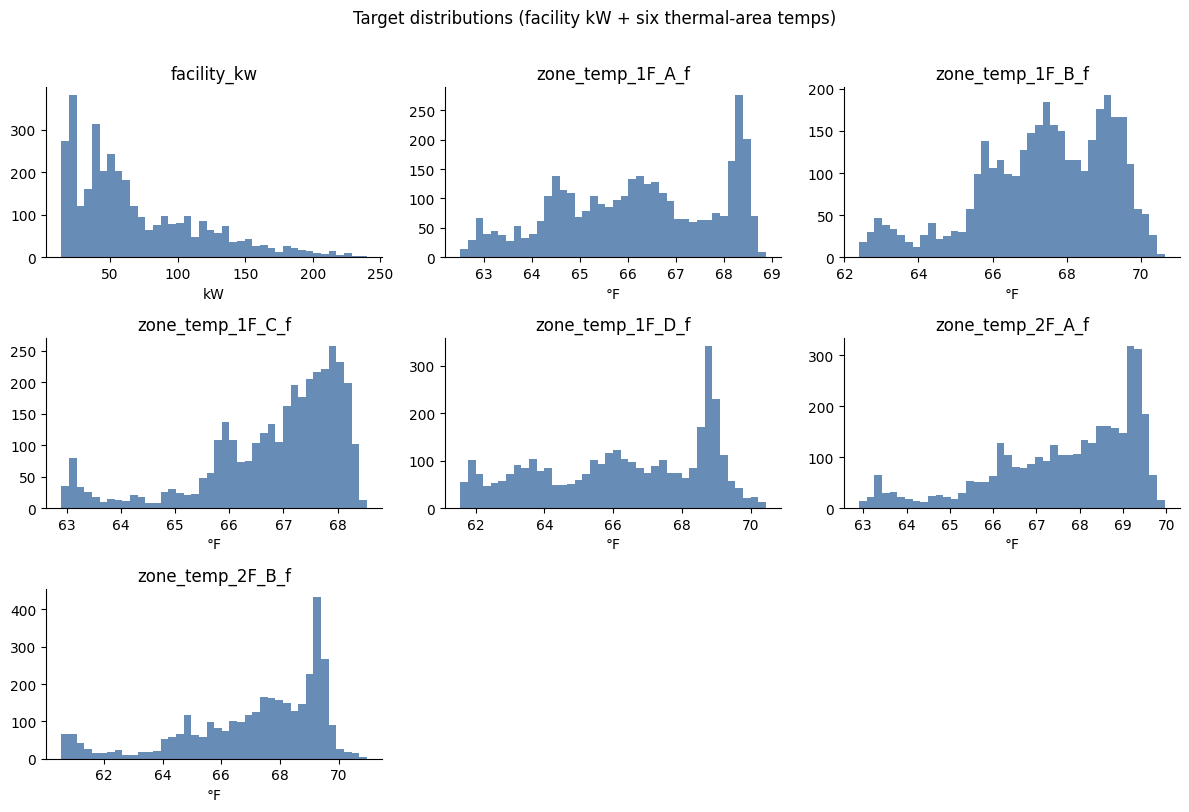

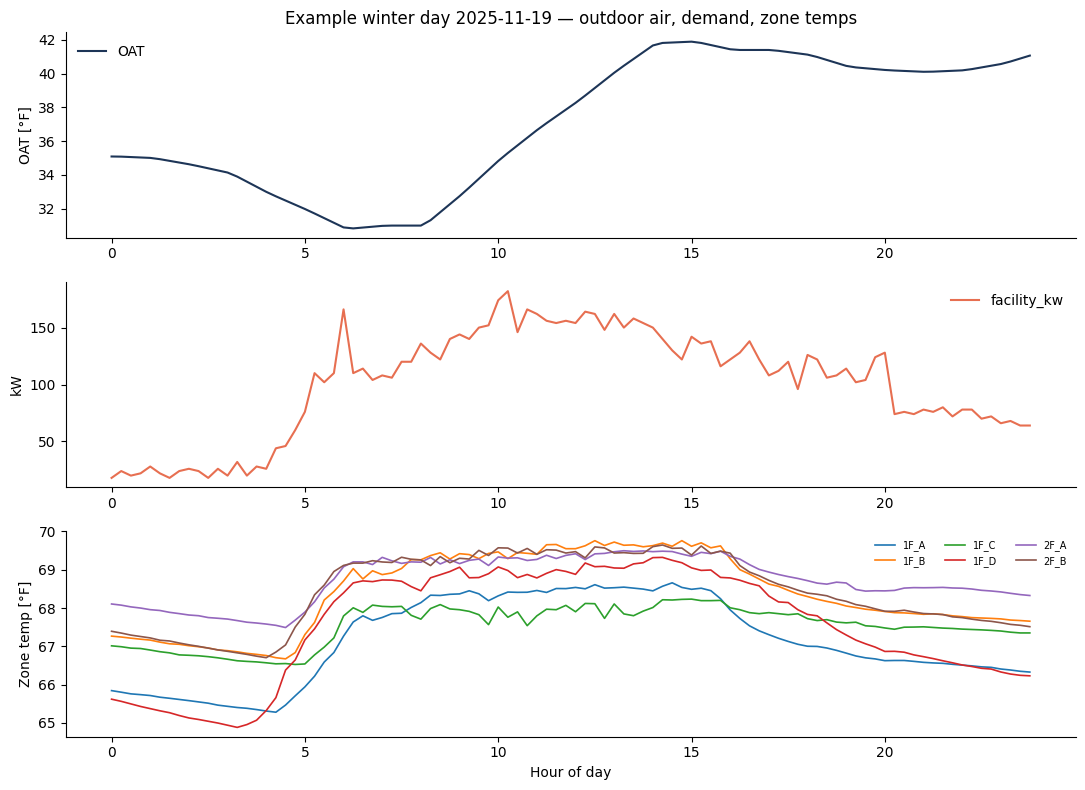

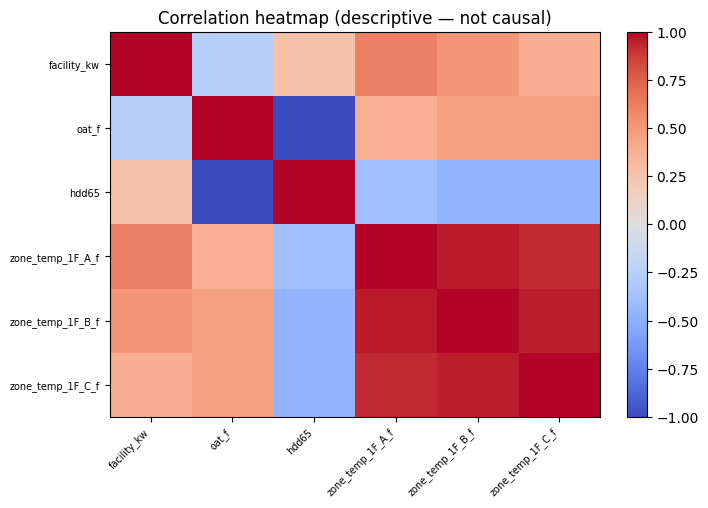

In [4]:
fig, ax = plt.subplots(figsize=(10, 2.2))
coverage_timeline(train_df, ax=ax)
save_fig(PATHS["figures"] / "sklearn_coverage.png", fig)
plt.close(fig)

cols_miss = [c for c in ["facility_kw", "oat_f", *ZONE_TEMP_COLS] if c in train_df.columns]
fig, ax = plt.subplots(figsize=(8, 3.5))
missingness_summary(train_df, cols_miss, ax=ax)
save_fig(PATHS["figures"] / "sklearn_missingness.png", fig)
plt.close(fig)

fig = target_distributions(train_df)
save_fig(PATHS["figures"] / "sklearn_target_dist.png", fig)
plt.close(fig)

example_day = str(sorted(train_df["day"].astype(str).unique())[len(train_df["day"].unique()) // 2])
fig = winter_day_panel(train_df, example_day)
save_fig(PATHS["figures"] / "sklearn_winter_day.png", fig)
plt.close(fig)

corr_cols = [c for c in ["facility_kw", "oat_f", "hdd65", *ZONE_TEMP_COLS[:3]] if c in train_df.columns]
fig, ax = plt.subplots(figsize=(7, 5))
descriptive_corr_heatmap(train_df, corr_cols, ax=ax)
save_fig(PATHS["figures"] / "sklearn_corr.png", fig)
plt.close(fig)


## Paired E+ farm proof (component B data) — separate stream


In [5]:
try:
    farm_df, farm_meta = prove_native_farm_load()
    print("farm rows", len(farm_df), "— still NOT concatenated with BAS for training")
except Exception as e:
    farm_df, farm_meta = None, {}
    print("farm proof skipped / unavailable:", e)
    display(Markdown(
        "Paired farm not loaded here; Train B will call `load_paired_and_build_delta` "
        "which expects `ENERGYPLUS_NATIVE_RUN` paired parquet under artifacts."
    ))


farm proof skipped / unavailable: prove_native_farm_load() missing 2 required keyword-only arguments: 'root' and 'paths'


Paired farm not loaded here; Train B will call `load_paired_and_build_delta` which expects `ENERGYPLUS_NATIVE_RUN` paired parquet under artifacts.

## 8 · Chronological design (SoT)

One shared `eval/split_manifest.json` from `chrono_splits.build_split_manifest`:

1. **Heating days** only (mean OAT ≤ 50 °F or HDD-hours rule).
2. **Final winter test** — last ~15–20% of Dec/Jan/Feb heating days — **locked**, never used for champion selection.
3. Remaining **dev days** → rolling-origin folds with a **1-day embargo** between train end and validation start.
4. Champion = best **recursive** peak MAE on rolling val; score locked test once after selection.


wrote C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\eval\split_manifest.json
dev_days 35 final_winter_test 1 folds 3
  fold1: train=10 val=8 embargo=1
  fold2: train=18 val=8 embargo=1
  fold3: train=26 val=8 embargo=1


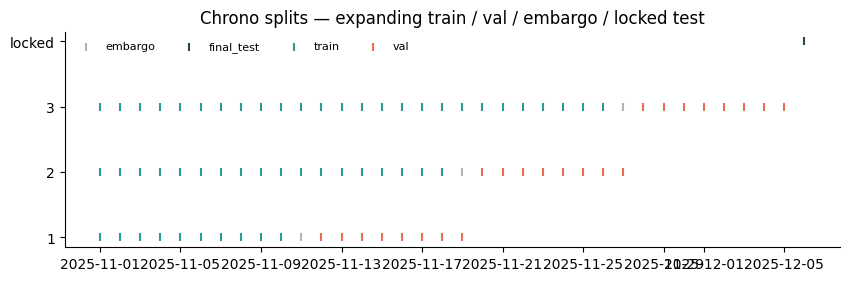

In [6]:
split_manifest = build_split_manifest(train_df)
split_path = write_manifest(OUT / "eval" / "split_manifest.json", split_manifest)
print("wrote", split_path)
print("dev_days", len(split_manifest.get("dev_days", [])),
      "final_winter_test", len(split_manifest.get("final_winter_test", [])),
      "folds", len(split_manifest.get("folds", [])))
for i, f in enumerate(split_manifest.get("folds", [])):
    print(f"  fold{i+1}: train={len(f['train'])} val={len(f['val'])} embargo={len(f.get('embargo', []))}")

# Simple chrono viz
rows = []
for i, f in enumerate(split_manifest.get("folds", [])):
    for role, days in (("train", f["train"]), ("val", f["val"]), ("embargo", f.get("embargo", []))):
        for d in days:
            rows.append({"fold": i + 1, "role": role, "day": str(d)})
for d in split_manifest.get("final_winter_test", []):
    rows.append({"fold": "locked", "role": "final_test", "day": str(d)})
split_df = pd.DataFrame(rows)
if len(split_df):
    fig, ax = plt.subplots(figsize=(10, 2.8))
    colors = {"train": "#2a9d8f", "val": "#e76f51", "embargo": "#adb5bd", "final_test": "#264653"}
    for role, g in split_df.groupby("role"):
        ax.scatter(pd.to_datetime(g["day"]), g["fold"].astype(str), s=28, c=colors.get(role, "#888"), label=role, marker="|")
    ax.set_title("Chrono splits — expanding train / val / embargo / locked test")
    ax.legend(frameon=False, fontsize=8, ncol=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    save_fig(PATHS["figures"] / "sklearn_chrono_splits.png", fig)
    plt.close(fig)


## 9 · Naive baselines

Persistence (lag-1 as prediction) and same-hour-of-day means set the bar. A champion that cannot beat persistence on morning peak is not shippable for screening, let alone operations.


## 10 · Architectures (sklearn hybrid)

**Component A** — multi-output ExtraTrees / RF / GB / Ridge bake-off on real BAS.  
**Component B** — multi-output delta model on paired IdealLoads strategies.  
Lean mode (`FULL=False`) uses fixed hyperparams + ~36 winter days for CI-ish runtime. Set `FULL=True` for nested CV.


## 11 · Teacher-forcing vs recursive (why both appear)

Teacher-forced OOF is useful to see whether the function class can fit one-step dynamics.  
**Operational walks are recursive:** errors compound through lag feedback. Cards therefore lead with
`cv_recursive_96_heldout` / locked-test recursive blocks. TF alone is never enough to promote.


## 12 · 96-step evaluation contract

Per held-out day: facility MAE/RMSE, peak MAE, daily peak mag/timing, daily kWh error,
zone MAE mean + per zone, horizon MAE at steps 1/4/12/24/48/96 via `evaluate_recursive_days`.


## Train A — real baseline (`lean_bake_off`)


In [7]:
if FULL:
    base_result = nested_bake_off(
        train_df, outer_splits=N_SPLITS, split_manifest=split_manifest, out_dir=OUT
    )
else:
    base_result = lean_bake_off(
        train_df, n_splits=N_SPLITS, split_manifest=split_manifest, out_dir=OUT
    )
base_result["run_id"] = run_id

display(Markdown("### Naive baselines (from bake-off)"))
bl = base_result.get("baselines") or {}
display(pd.DataFrame(bl).T if bl else pd.DataFrame({"note": ["no baselines in result"]}))

display(Markdown("### Teacher-forced CV (diagnostic)"))
display(pd.DataFrame(base_result.get("cv_teacher_forced", {})).T)

display(Markdown("### Recursive held-out CV (selection metric)"))
rec = base_result.get("cv_recursive_96_heldout") or {}
display(pd.DataFrame(rec).T if isinstance(rec, dict) and rec and not any(k in rec for k in ("status", "note")) else pd.Series(rec).to_frame("value") if rec else pd.DataFrame({"note": ["empty"]}))

print("champion", base_result.get("champion"))


### Naive baselines (from bake-off)

,facility_kw_mae,facility_kw_mae_peak_05_09
n_eval_days,1.000000,1.000000
persistence_lag1,6.041667,7.647059
same_hour_of_day_mean,27.803571,47.445378


### Teacher-forced CV (diagnostic)

,facility_kw,zone_temp_1F_A_f,zone_temp_1F_B_f,zone_temp_1F_C_f,zone_temp_1F_D_f,zone_temp_2F_A_f,zone_temp_2F_B_f,facility_kw_mae,facility_kw_mae_peak_05_09,zone_temp_mae_mean
random_forest,"{'mae': 11.361672888502497, 'rmse': 15.6898431...","{'mae': 0.16268737980058734, 'rmse': 0.2339918...","{'mae': 0.2273730895283449, 'rmse': 0.34190695...","{'mae': 0.24786097228443116, 'rmse': 0.3737988...","{'mae': 0.19233669075511925, 'rmse': 0.2584864...","{'mae': 0.2191625578951419, 'rmse': 0.33338669...","{'mae': 0.3273217529549212, 'rmse': 0.50881922...",11.361673,16.106126,0.229457
extra_trees,"{'mae': 12.277111291778885, 'rmse': 16.8066842...","{'mae': 0.1947743926484674, 'rmse': 0.27739941...","{'mae': 0.2662157720676307, 'rmse': 0.39207763...","{'mae': 0.2698450413901668, 'rmse': 0.40369139...","{'mae': 0.27512820792283293, 'rmse': 0.3836406...","{'mae': 0.29888144578435916, 'rmse': 0.4027063...","{'mae': 0.39922539096771875, 'rmse': 0.5964809...",12.277111,16.249533,0.284012
gradient_boosting,"{'mae': 11.19575651059666, 'rmse': 15.45666175...","{'mae': 0.17145925881030358, 'rmse': 0.2477038...","{'mae': 0.23519542699572024, 'rmse': 0.3558114...","{'mae': 0.24653323441132535, 'rmse': 0.3646825...","{'mae': 0.2136535622892927, 'rmse': 0.29743602...","{'mae': 0.2313370295322126, 'rmse': 0.34029528...","{'mae': 0.37040604448278874, 'rmse': 0.5767768...",11.195757,15.374856,0.244764


### Recursive held-out CV (selection metric)

,n_heldout_days,daily_kwh_error,daily_peak_mag_error_kw,facility_kw_mae,facility_kw_mae_peak_05_09,facility_kw_rmse,horizon_mae_step_1,horizon_mae_step_12,horizon_mae_step_24,horizon_mae_step_4,...,horizon_mae_step_96,n_steps,peak_timing_abs_error_steps,zone_mae_zone_temp_1F_A_f,zone_mae_zone_temp_1F_B_f,zone_mae_zone_temp_1F_C_f,zone_mae_zone_temp_1F_D_f,zone_mae_zone_temp_2F_A_f,zone_mae_zone_temp_2F_B_f,zone_temp_mae_mean
random_forest,24.0,1013.923050,53.578309,50.491232,50.341706,59.718380,4.892019,37.521762,52.422480,14.408295,...,74.590496,96.0,16.375000,1.119849,1.089709,0.802066,1.727244,0.899453,1.513509,1.191972
extra_trees,24.0,473.096466,42.701317,30.660705,36.759664,37.660730,6.504562,53.514693,39.080498,26.091341,...,17.900542,96.0,17.291667,0.872436,1.012441,0.761176,1.364028,0.996544,1.380791,1.064569
gradient_boosting,24.0,590.782778,46.048000,37.494820,46.859333,46.774404,6.500278,47.907307,53.743219,20.612286,...,31.448178,96.0,19.208333,1.109813,1.131296,0.854115,1.384193,1.080633,1.468035,1.171347


champion extra_trees


run_id: sklearn_tutorial_20260806T203515Z_eb4a7d


  joblib: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\real_baseline_15min_v1.joblib


    sha256=7ebcb37df1ac982898f6f9ae03f621e2dc2f6c64b88e76eec00b2d242270a9b4


  onnx: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\real_baseline_15min_v1.onnx


    sha256=70baa64477037e026ac8aaf9b5a72fd49f9b3f7df5689adfd0dd661c4793267e


...

  meta: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\real_baseline_15min_v1_feature_meta.json


    sha256=cca664e10fc7530851456168343d51579d96f6b554b7f6c066984974f6f483fd


  card: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\real_baseline_15min_v1_model_card.json


    sha256=5bd55b1c6518d3448aeed02d620a3e08e608c6aaa3fb90668a6e36e9925b5dc4


family bars skipped: 'mae_peak_05_09'


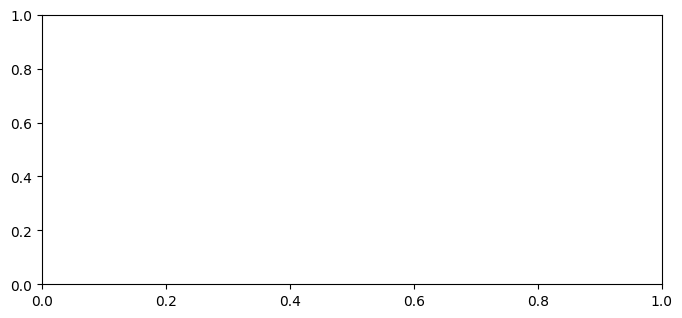

In [8]:
paths_a = export_real_baseline_artifacts(base_result, OUT)
base_card = json.loads(paths_a["card"].read_text(encoding="utf-8"))
print("A card", paths_a["card"])
print("hashes", json.dumps(base_card.get("hashes") or base_card.get("artifact_sha256") or {}, indent=2))
reg_a = artifact_registry({k: v for k, v in paths_a.items()}, run_id=run_id)
print_artifact_registry(reg_a)

# Family bars if recursive peak metrics present
try:
    cv_for_bars = {}
    raw = base_result.get("cv_recursive_96_heldout") or {}
    if isinstance(raw, dict):
        for fam, m in raw.items():
            if isinstance(m, dict) and "facility_kw_mae_peak_05_09" in m:
                cv_for_bars[fam] = m
    if cv_for_bars:
        fig, ax = plt.subplots(figsize=(8, 3.5))
        family_mae_bars(cv_for_bars, ax=ax, title="Sklearn families — recursive peak MAE", highlight=base_result.get("champion"))
        save_fig(PATHS["figures"] / "sklearn_family_bars.png", fig)
        plt.close(fig)
except Exception as e:
    print("family bars skipped:", e)


## Train B — E+ delta (`lean_train_delta`)


In [9]:
delta_df, paired_path = load_paired_and_build_delta(out_dir=OUT)
if FULL:
    delta_result = train_delta(delta_df)
else:
    delta_result = lean_train_delta(delta_df, n_splits=N_SPLITS)
delta_result["run_id"] = run_id
paths_b = export_delta_artifacts(delta_result, OUT, paired_source=str(paired_path))
delta_card = json.loads(paths_b["card"].read_text(encoding="utf-8"))
print("B champion", delta_result.get("champion"), "n_days", delta_card.get("n_days"))
print("limitation:", delta_card.get("limitation"))
print("B card", paths_b["card"])
print("B hashes", json.dumps(delta_card.get("hashes") or {}, indent=2))
reg_b = artifact_registry({k: v for k, v in paths_b.items()}, run_id=run_id)
print_artifact_registry(reg_b)


delta rows=576 pairs=6 -> C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\eplus_delta_15min_v1.parquet


lean delta fold 1/3


  random_forest peak dMAE=57.408


  extra_trees peak dMAE=53.344


  gradient_boosting peak dMAE=58.010


...

    sha256=cba460a65551f7bfd4ee01c6a146005f054ebe2131db0fb3e5a9cd665e6a0340


  meta: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\eplus_delta_15min_v1_feature_meta.json


    sha256=3893a98d496a7f100b611a40a968b8814b2f6fe78711c8a4d380db6138b45e94


  card: C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\eplus_delta_15min_v1_model_card.json


    sha256=8dbca3e42d906b2cf7aeee75842953c4515deff7f72047e4ab7cf1b7be60efe9


## 13 · Facility (kW) results

Interpret morning-peak MAE against persistence. Prefer recursive numbers from the model card over any in-notebook hardcodes.


## 14 · Per-zone results (never hide the worst zone)

Show a per-target table and small multiples when predictions exist. Zone MAE should be a few °F if training worked — not ~24 °F.


### Per-target view from component A card (recursive where available)

,target,unit,recursive_mae,recursive_peak_mae,tf_mae,zone_temp_mae_mean,worst_zone_mae
0,facility_kw,kW,30.660705,36.759664,12.277111,1.064569,None


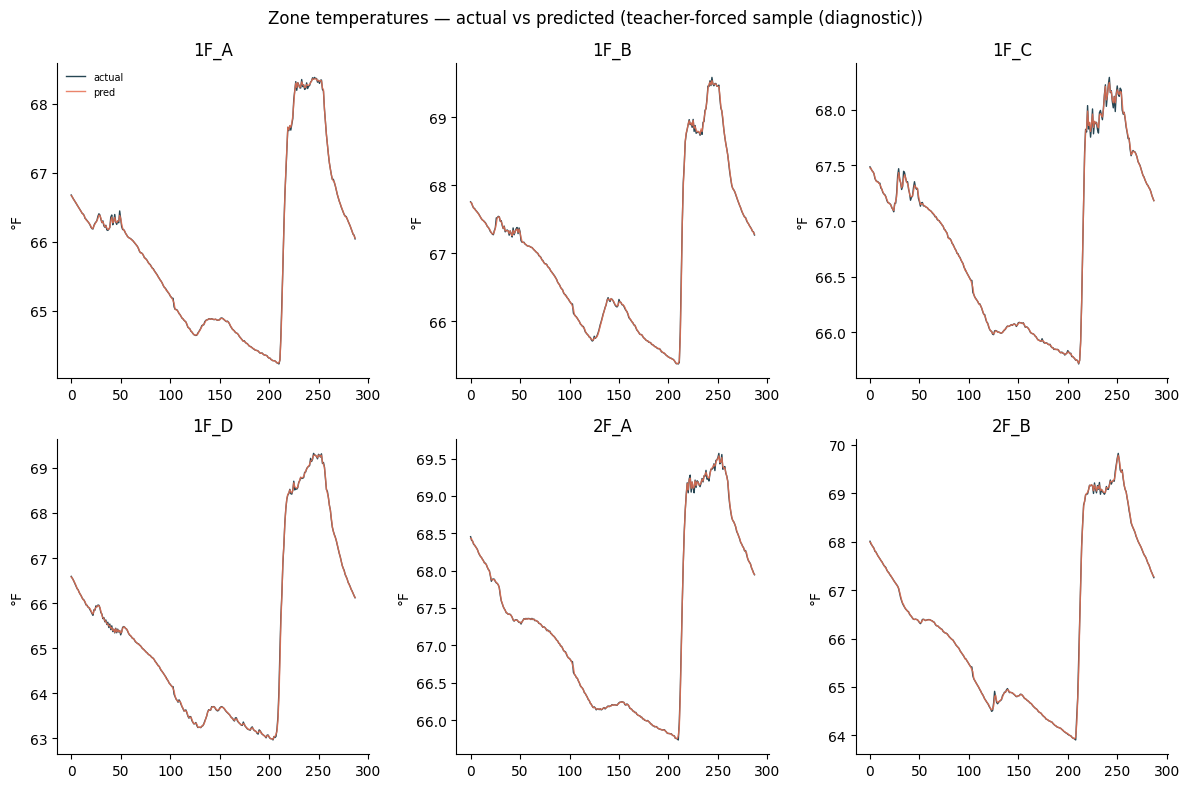

In [10]:
display(Markdown("### Per-target view from component A card (recursive where available)"))

def _flatten_champ_metrics(card: dict) -> pd.DataFrame:
    champ = card.get("champion")
    rec = card.get("cv_recursive_96_heldout") or {}
    tf = card.get("cv_teacher_forced") or {}
    # Prefer champion block if nested by family
    block = rec.get(champ, rec) if isinstance(rec, dict) else {}
    if not isinstance(block, dict):
        block = {}
    rows = []
    # facility
    rows.append({
        "target": "facility_kw",
        "unit": "kW",
        "recursive_mae": block.get("facility_kw_mae"),
        "recursive_peak_mae": block.get("facility_kw_mae_peak_05_09"),
        "tf_mae": (tf.get(champ) or tf).get("facility_kw_mae") if isinstance(tf, dict) else None,
        "zone_temp_mae_mean": block.get("zone_temp_mae_mean"),
        "worst_zone_mae": block.get("worst_zone_mae"),
    })
    # per-zone if present
    zmap = block.get("zone_mae") or block.get("zone_temp_mae") or {}
    if isinstance(zmap, dict):
        for z, v in zmap.items():
            rows.append({"target": z, "unit": "°F", "recursive_mae": v})
    return pd.DataFrame(rows)

tbl_a = _flatten_champ_metrics(base_card)
display(tbl_a)

# Zone small multiples if OOF / held-out preds exist on result
yt = base_result.get("Y")
# Try eval JSON for a sample day plot from card tables only if no preds
eval_json = OUT / "eval" / "baseline_recursive_days.json"
if yt is not None and base_result.get("model") is not None and base_result.get("X") is not None:
    # Teacher-forced sample for viz only (labeled)
    pred = base_result["model"].predict(base_result["X"][: min(96 * 3, len(base_result["X"]))])
    y_true = base_result["Y"][: len(pred)]
    fig = zone_small_multiples(y_true[:, 1:], pred[:, 1:], split_label="teacher-forced sample (diagnostic)")
    save_fig(PATHS["figures"] / "sklearn_zone_small_multiples.png", fig)
    plt.close(fig)
elif eval_json.is_file():
    display(Markdown(f"OOF tensors unavailable — see `{eval_json.name}` and card tables above for zone MAE."))
else:
    display(Markdown("Zone MAE from card tables only (no OOF tensors in lean result for plotting)."))
    display(tbl_a[tbl_a["unit"] == "°F"] if "unit" in tbl_a.columns else tbl_a)


## 15 · DSM / comfort context

Hybrid walk shades HE 05–09 and overlays comfort bands (±2 °F around 68 °F occupied SP).  
IdealLoads + fixed COP ≠ GSHP plant — screening only.


## Hybrid promote — fail-closed, then smoke watermark

Expect **default promote to refuse** on an underpowered (<12 pair) farm.
Smoke path sets `VIBE22_ALLOW_SMOKE_PROMOTE=1` and stamps `UNDERPOWERED_SMOKE_FARM` — still **not** operational DSM.


default promote refused (expected) — candidate NOT promoted:
  usable both-arm pairs=6 < MIN_PAIRS=12. Refuse promote unless VIBE22_ALLOW_SMOKE_PROMOTE=1 (smoke/dev only). Grow the paired E+ farm or set the env explicitly.


smoke promote ship_mode smoke_artifact watermark UNDERPOWERED_SMOKE_FARM
walk C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\hybrid_dsm_96_v1_walk.json


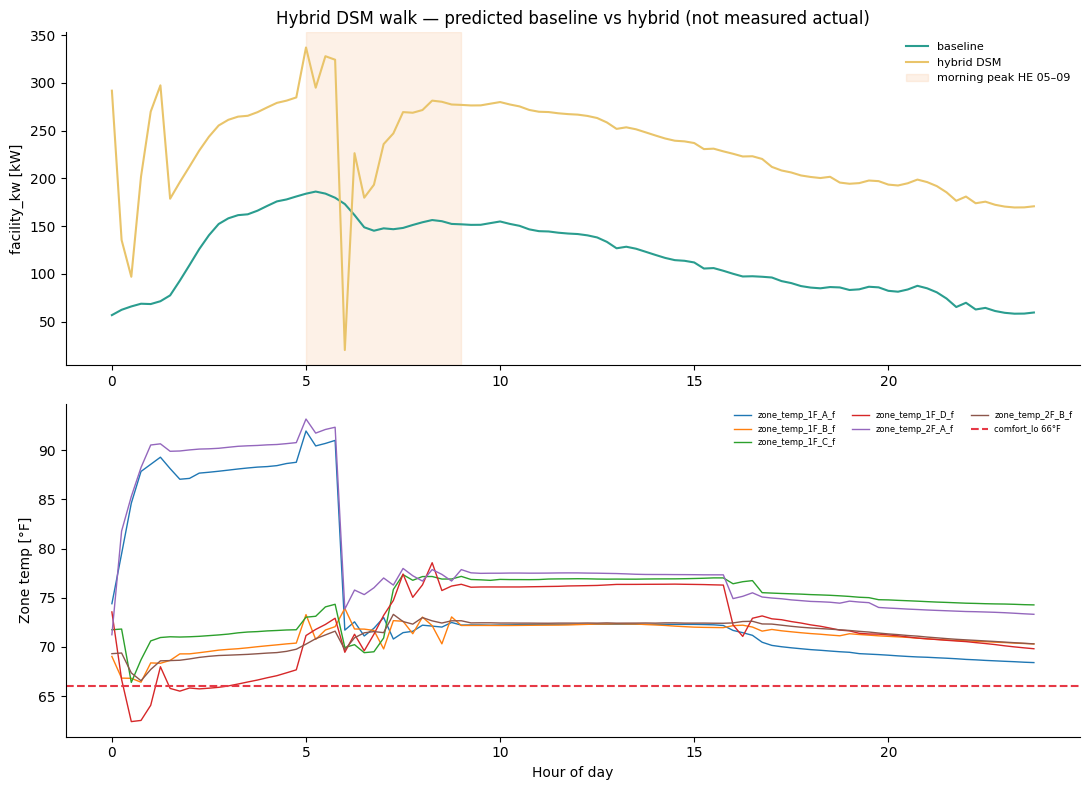

### Walk summary

,value
cumulative_kwh_baseline,2833.527323
cumulative_kwh_hybrid,5569.025285
peak_kw_baseline,186.177778
peak_kw_hybrid,336.962654
peak_step_baseline,21.000000
peak_step_hybrid,20.000000
comfort_violations,9.000000
delta_peak_kw,150.784877
delta_kwh,2735.497962


In [11]:
# 1) Without smoke — expect failure (candidate not promoted)
os.environ.pop(SMOKE_ENV, None)
promote_default_ok = False
promote_default_err = None
try:
    promote_hybrid(artifacts=OUT, desktop_artifacts=ROOT / "desktop" / "artifacts")
    promote_default_ok = True
    raise AssertionError("promote should fail without smoke on under-covered farm")
except (ValueError, AssertionError) as e:
    promote_default_err = str(e)
    print("default promote refused (expected) — candidate NOT promoted:")
    print(" ", promote_default_err)

# 2) Smoke watermark path
os.environ[SMOKE_ENV] = "1"
promo = promote_hybrid(artifacts=OUT, desktop_artifacts=ROOT / "desktop" / "artifacts")
walk = promo["result"]
assert walk.get("honesty") == "HYBRID_SCREENING"
assert len(walk["steps"]) == 96

ship_path = ROOT / "desktop" / "artifacts" / "hybrid_ship_manifest.json"
ship = json.loads(ship_path.read_text(encoding="utf-8")) if ship_path.is_file() else {}
print("smoke promote ship_mode", ship.get("ship_mode"), "watermark", ship.get("watermark"))
print("walk", promo.get("walk"))

fig = hybrid_walk_panel(walk)
save_fig(PATHS["figures"] / "sklearn_hybrid_walk.png", fig)
plt.close(fig)
display(Markdown("### Walk summary"))
display(pd.Series(walk.get("summary") or {}).to_frame("value"))


## 16 · Limitations

- Smoke farm underpowered (<12 both-arm pairs) → promote refuses unless watermarked smoke path.
- Strategy, date, and weather remain confounded on the E+ delta arm.
- Geometry is rectangular program massing, not CAD.
- Utility G14 ≠ interval-integrated demand fidelity.


## 17 · Reproduction

```powershell
$env:LAKESIDE_SITE_ROOT="C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"
# Preferred: open this notebook → Run All
# CLI (gated): $env:VIBE22_ALLOW_CLI_TRAIN="1"
#   python -u scripts/run_sklearn_tutorial_train.py --max-days 36
#   python -u scripts/run_torch_tutorial_train.py --lean --max-days 36
```

Artifacts print absolute paths + SHA-256 via `run_provenance`.


## Tutorial and Research Benchmark — Not Approved for Operational DSM

This cell is **metric-driven** from cards / ship manifest — not hardcoded success.


In [12]:
base_card = json.loads((OUT / "real_baseline_15min_v1_model_card.json").read_text(encoding="utf-8"))
delta_card = json.loads((OUT / "eplus_delta_15min_v1_model_card.json").read_text(encoding="utf-8"))
ship_path = ROOT / "desktop" / "artifacts" / "hybrid_ship_manifest.json"
ship = json.loads(ship_path.read_text(encoding="utf-8")) if ship_path.is_file() else {}

def _held_status(card: dict) -> str:
    h = card.get("cv_recursive_96_heldout")
    if not h:
        return "not_evaluated"
    if isinstance(h, dict) and h.get("status"):
        return str(h["status"])
    if isinstance(h, dict) and h.get("note"):
        return str(h["note"])
    # nested by family
    champ = card.get("champion")
    if isinstance(h, dict) and champ in h and isinstance(h[champ], dict):
        m = h[champ]
        if m.get("facility_kw_mae") is not None or m.get("facility_kw_mae_peak_05_09") is not None:
            return "evaluated"
    if isinstance(h, dict) and any(
        isinstance(v, dict) and (v.get("facility_kw_mae") is not None) for v in h.values()
    ):
        return "evaluated"
    return "not_evaluated"

gates = [
    {"gate": "honesty HYBRID_SCREENING (A)", "PASS": base_card.get("honesty") == "HYBRID_SCREENING"},
    {"gate": "honesty HYBRID_SCREENING (B)", "PASS": delta_card.get("honesty") == "HYBRID_SCREENING"},
    {"gate": "A recursive held-out present", "PASS": _held_status(base_card) == "evaluated"},
    {"gate": "B recursive held-out present", "PASS": _held_status(delta_card) not in ("not_evaluated", "")},
    {"gate": "default promote refused without smoke", "PASS": not promote_default_ok},
    {"gate": "smoke ship watermarked (not operational)", "PASS": ship.get("ship_mode") == "smoke_artifact" or bool(ship.get("watermark"))},
    {"gate": "DO NOT RELEASE FOR OPERATIONAL DSM", "PASS": True},
]
gate_df = pd.DataFrame(gates)
display(Markdown("### PASS / FAIL — research benchmark only"))
display(gate_df)

champ = base_card.get("champion")
rec = base_card.get("cv_recursive_96_heldout") or {}
block = rec.get(champ, rec) if isinstance(rec, dict) else {}
peak = block.get("facility_kw_mae_peak_05_09") if isinstance(block, dict) else None
zone = block.get("zone_temp_mae_mean") if isinstance(block, dict) else None
lines = [
    f"- **run_id:** `{run_id}`",
    f"- **A champion:** `{champ}` · recursive peak MAE={peak} kW · zone_mean MAE={zone} °F",
    f"- **B champion:** `{delta_card.get('champion')}` · limitation: {delta_card.get('limitation')}",
    f"- **Ship mode:** `{ship.get('ship_mode')}` watermark=`{ship.get('watermark')}`",
    "- **Verdict:** Tutorial / research benchmark under **`HYBRID_SCREENING`** — "
    "**Not Approved for Operational DSM.**",
]
display(Markdown("\n".join(lines)))
assert gate_df["PASS"].all() or (gate_df.loc[gate_df["gate"].str.contains("recursive"), "PASS"].any()), gate_df
print("Final honesty: HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM")


### PASS / FAIL — research benchmark only

,gate,PASS
0,honesty HYBRID_SCREENING (A),True
1,honesty HYBRID_SCREENING (B),True
2,A recursive held-out present,True
3,B recursive held-out present,False
4,default promote refused without smoke,True
5,smoke ship watermarked (not operational),True
6,DO NOT RELEASE FOR OPERATIONAL DSM,True


- **run_id:** `sklearn_tutorial_20260806T203515Z_eb4a7d`
- **A champion:** `extra_trees` · recursive peak MAE=36.75966405775096 kW · zone_mean MAE=1.0645692938486202 °F
- **B champion:** `gradient_boosting` · limitation: strategy, date, and weather remain confounded; smoke farm underpowered
- **Ship mode:** `smoke_artifact` watermark=`UNDERPOWERED_SMOKE_FARM`
- **Verdict:** Tutorial / research benchmark under **`HYBRID_SCREENING`** — **Not Approved for Operational DSM.**

Final honesty: HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM
